# Exploratory Data Analysis (EDA): Mental Health in Tech Survey
## DS Intern Project - Comprehensive Pipeline

This notebook provides an end-to-end EDA pipeline for analyzing mental health attitudes and experiences in the tech industry.


## 1. Environment Setup & Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('survey.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1259, 27)

First few rows:


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 2. Data Overview & Structure

In [3]:
# Dataset information
print("Dataset Information:")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"\nColumn Names and Types:")
print(df.dtypes)

Dataset Information:
Total Records: 1259
Total Features: 27

Column Names and Types:
Timestamp                      str
Age                          int64
Gender                         str
Country                        str
state                          str
self_employed                  str
family_history                 str
treatment                      str
work_interfere                 str
no_employees                   str
remote_work                    str
tech_company                   str
benefits                       str
care_options                   str
wellness_program               str
seek_help                      str
anonymity                      str
leave                          str
mental_health_consequence      str
phys_health_consequence        str
coworkers                      str
supervisor                     str
mental_health_interview        str
phys_health_interview          str
mental_vs_physical             str
obs_consequence                str
comme

In [4]:
# Display basic statistics
print("\nBasic Statistics:")
df.describe(include='all').T


Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Values Analysis

In [5]:
# Calculate missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Values Analysis:")
print(missing_df)
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing Values Analysis:
                                              Column  Missing_Count  \
comments                                    comments           1095   
state                                          state            515   
work_interfere                        work_interfere            264   
self_employed                          self_employed             18   
seek_help                                  seek_help              0   
obs_consequence                      obs_consequence              0   
mental_vs_physical                mental_vs_physical              0   
phys_health_interview          phys_health_interview              0   
mental_health_interview      mental_health_interview              0   
supervisor                                supervisor              0   
coworkers                                  coworkers              0   
phys_health_consequence      phys_health_consequence              0   
mental_health_consequence  mental_health_consequence

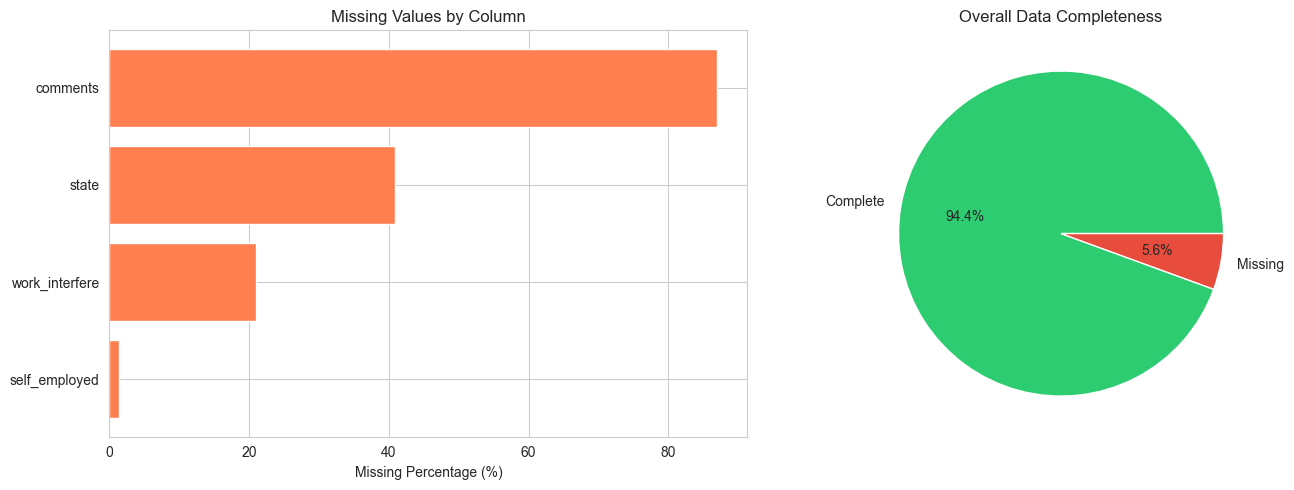

Overall data completeness: 94.43%


In [6]:
# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values bar plot
missing_data = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=True)
axes[0].barh(missing_data['Column'], missing_data['Missing_Percentage'], color='coral')
axes[0].set_xlabel('Missing Percentage (%)')
axes[0].set_title('Missing Values by Column')

# Pie chart of data completeness
total_cells = df.shape[0] * df.shape[1]
complete = total_cells - df.isnull().sum().sum()
missing = df.isnull().sum().sum()
axes[1].pie([complete, missing], labels=['Complete', 'Missing'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Overall Data Completeness')

plt.tight_layout()
plt.show()
print(f"Overall data completeness: {(complete/total_cells*100):.2f}%")

## 4. Data Cleaning & Preprocessing

In [7]:
# Create a copy for cleaning
df_clean = df.copy()

# Handle Gender standardization
print("Unique Gender values (before cleaning):")
print(df_clean['Gender'].unique())
print(f"Count: {df_clean['Gender'].nunique()}")

Unique Gender values (before cleaning):
<StringArray>
[                                        'Female',
                                              'M',
                                           'Male',
                                           'male',
                                         'female',
                                              'm',
                                       'Male-ish',
                                          'maile',
                                   'Trans-female',
                                     'Cis Female',
                                              'F',
                          'something kinda male?',
                                       'Cis Male',
                                          'Woman',
                                              'f',
                                            'Mal',
                                     'Male (CIS)',
                                 'queer/she/they',
                            

In [16]:
df_clean.drop(df_clean[(df_clean["Age"] < 0) | (df_clean["Age"] > 100)].index, inplace=True)


In [17]:
# Standardize gender values
def standardize_gender(gender):
    if pd.isna(gender):
        return np.nan
    gender_str = str(gender).lower().strip()
    if gender_str in ['m', 'male', 'mail', 'man', 'men', 'cis man', 'malr', 'mal']:
        return 'Male'
    elif gender_str in ['f', 'female', 'woman', 'women', 'cis woman', 'femail']:
        return 'Female'
    else:
        return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(standardize_gender)
print("Unique Gender values (after cleaning):")
print(df_clean['Gender'].value_counts(dropna=False))

Unique Gender values (after cleaning):
Gender
Male      977
Female    243
Other      34
Name: count, dtype: int64


In [18]:
# Create age bins for better analysis
df_clean['Age_Group'] = pd.cut(df_clean['Age'], 
                                 bins=[0, 25, 35, 45, 55, 100],
                                 labels=['18-25', '26-35', '36-45', '46-55', '55+'])

print("Age Group Distribution:")
print(df_clean['Age_Group'].value_counts().sort_index())

Age Group Distribution:
Age_Group
18-25    220
26-35    701
36-45    277
46-55     42
55+       14
Name: count, dtype: int64


In [19]:
# Check data types and convert timestamp
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
print(f"\nData after cleaning:")
print(df_clean.head())
print(f"\nCleaned dataset shape: {df_clean.shape}")


Data after cleaning:
            Timestamp  Age  Gender         Country state self_employed  \
0 2014-08-27 11:29:31   37  Female   United States    IL           NaN   
1 2014-08-27 11:29:37   44    Male   United States    IN           NaN   
2 2014-08-27 11:29:44   32    Male          Canada   NaN           NaN   
3 2014-08-27 11:29:46   31    Male  United Kingdom   NaN           NaN   
4 2014-08-27 11:30:22   31    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

  mental_health_consequence phys_health_consequence     coworkers supervisor  \
0                        No                      No  Som

## 5. Demographic Analysis

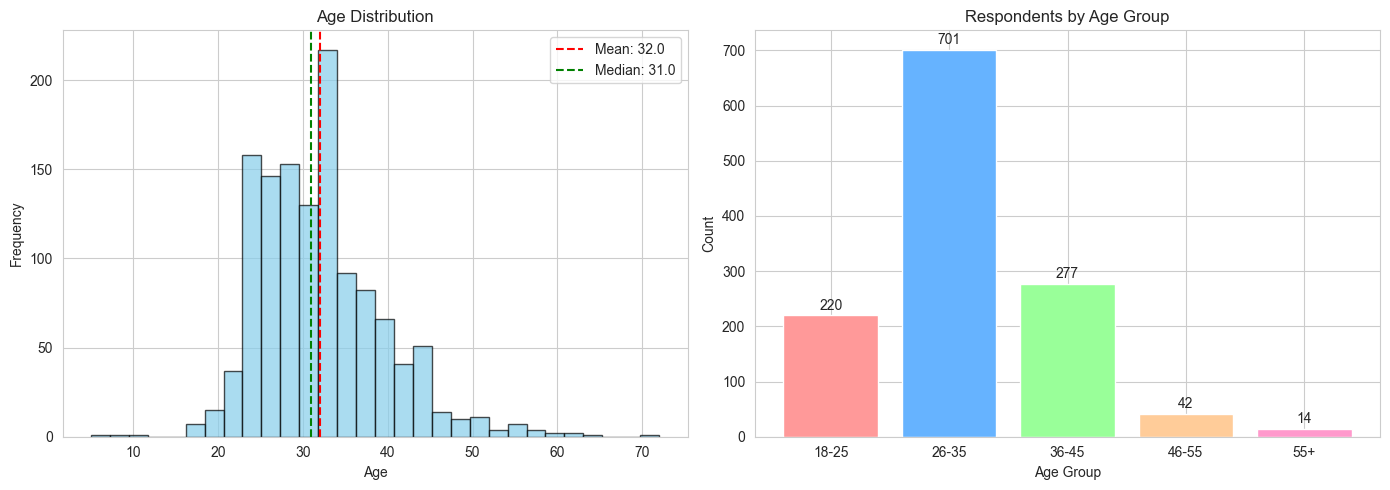

Age Statistics:
Mean: 32.02
Median: 31.00
Std Dev: 7.38
Min: 5
Max: 72


In [20]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['Age'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].axvline(df_clean['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Age"].mean():.1f}')
axes[0].axvline(df_clean['Age'].median(), color='green', linestyle='--', label=f'Median: {df_clean["Age"].median():.1f}')
axes[0].legend()

# Age group distribution
age_group_counts = df_clean['Age_Group'].value_counts().sort_index()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
axes[1].bar(age_group_counts.index, age_group_counts.values, color=colors)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].set_title('Respondents by Age Group')
for i, v in enumerate(age_group_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Age Statistics:")
print(f"Mean: {df_clean['Age'].mean():.2f}")
print(f"Median: {df_clean['Age'].median():.2f}")
print(f"Std Dev: {df_clean['Age'].std():.2f}")
print(f"Min: {df_clean['Age'].min():.0f}")
print(f"Max: {df_clean['Age'].max():.0f}")

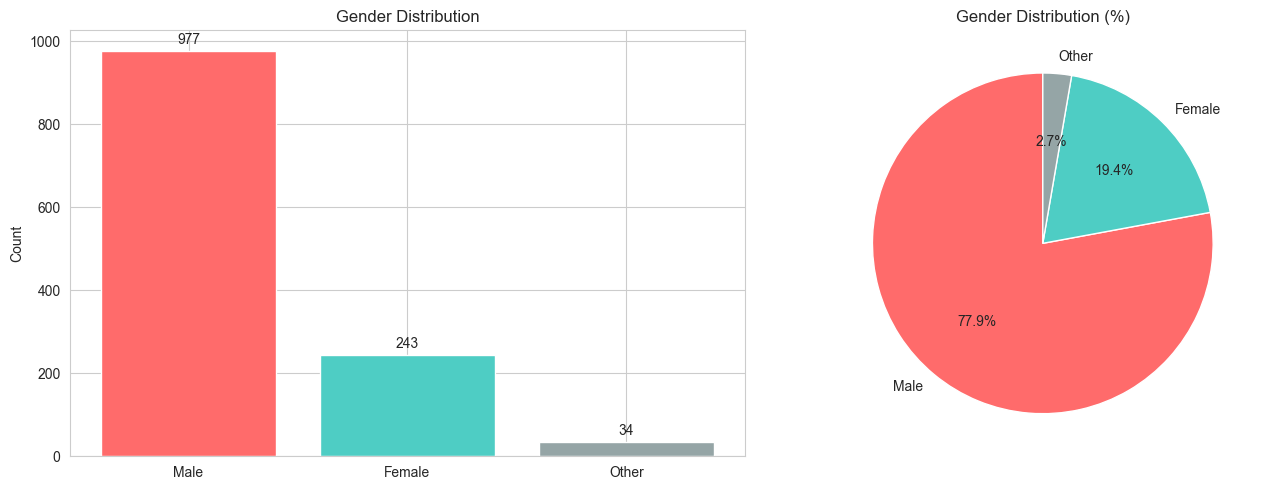

Gender Distribution:
Gender
Male      977
Female    243
Other      34
Name: count, dtype: int64

Gender Distribution (%):
Gender
Male      77.91
Female    19.38
Other      2.71
Name: count, dtype: float64


In [21]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
gender_counts = df_clean['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#ff6b6b', '#4ecdc4', '#95a5a6'])
axes[0].set_ylabel('Count')
axes[0].set_title('Gender Distribution')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom')

# Pie chart
colors = ['#ff6b6b', '#4ecdc4', '#95a5a6']
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Gender Distribution (%)')

plt.tight_layout()
plt.show()

print("Gender Distribution:")
print(gender_counts)
print(f"\nGender Distribution (%):\n{(gender_counts/len(df_clean)*100).round(2)}")

Top 10 Countries:
Country
United States     748
United Kingdom    184
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64


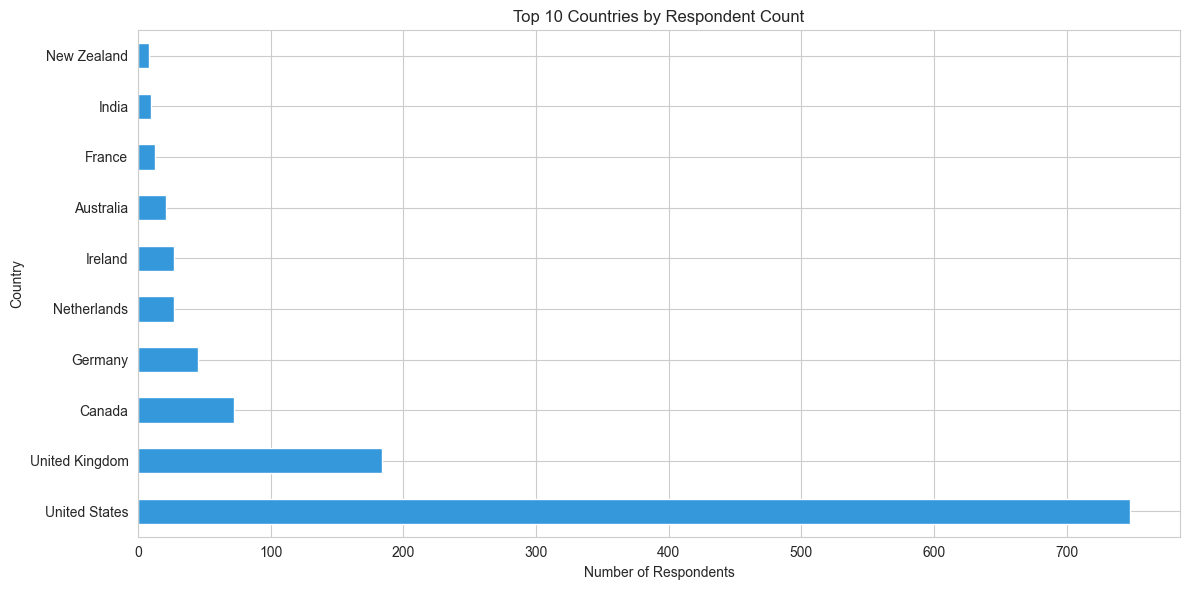

In [22]:
# Geographic distribution
print("Top 10 Countries:")
top_countries = df_clean['Country'].value_counts().head(10)
print(top_countries)

# Visualize top countries
fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Number of Respondents')
ax.set_title('Top 10 Countries by Respondent Count')
plt.tight_layout()
plt.show()

## 6. Employment & Company Analysis

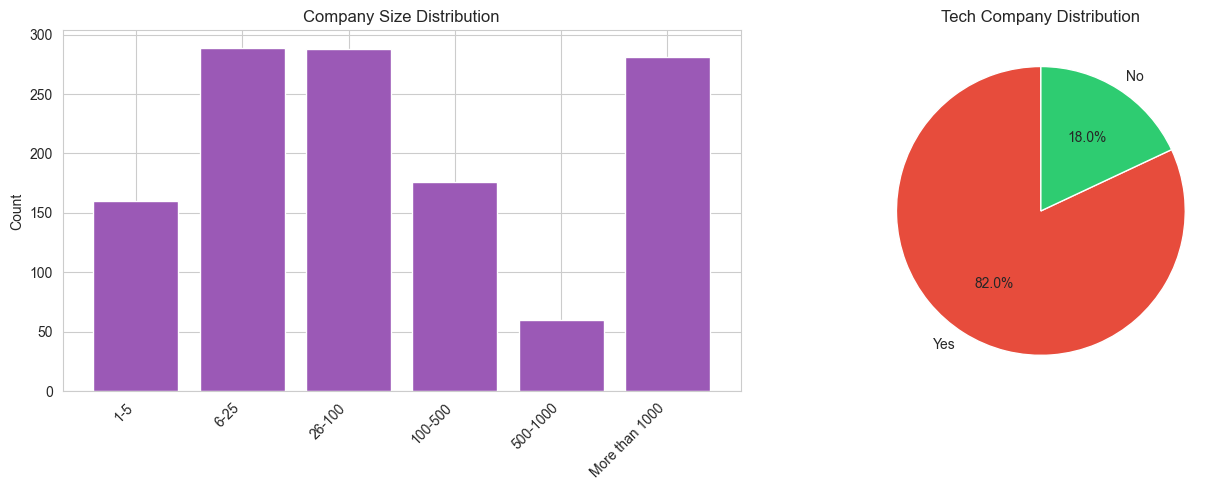

Company Size Distribution:
no_employees
1-5               160
6-25              289
26-100            288
100-500           176
500-1000           60
More than 1000    281
Name: count, dtype: int64

Tech Company Distribution:
tech_company
Yes    1028
No      226
Name: count, dtype: int64
Tech Companies: 81.98%


In [23]:
# Company size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
company_size = df_clean['no_employees'].value_counts()
company_size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
company_size = company_size.reindex([x for x in company_size_order if x in company_size.index])

axes[0].bar(range(len(company_size)), company_size.values, color='#9b59b6')
axes[0].set_xticks(range(len(company_size)))
axes[0].set_xticklabels(company_size.index, rotation=45, ha='right')
axes[0].set_ylabel('Count')
axes[0].set_title('Company Size Distribution')

# Tech company distribution
tech_company = df_clean['tech_company'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[1].pie(tech_company.values, labels=tech_company.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Tech Company Distribution')

plt.tight_layout()
plt.show()

print("Company Size Distribution:")
print(company_size)
print(f"\nTech Company Distribution:")
print(tech_company)
print(f"Tech Companies: {(tech_company.get('Yes', 0)/len(df_clean)*100):.2f}%")

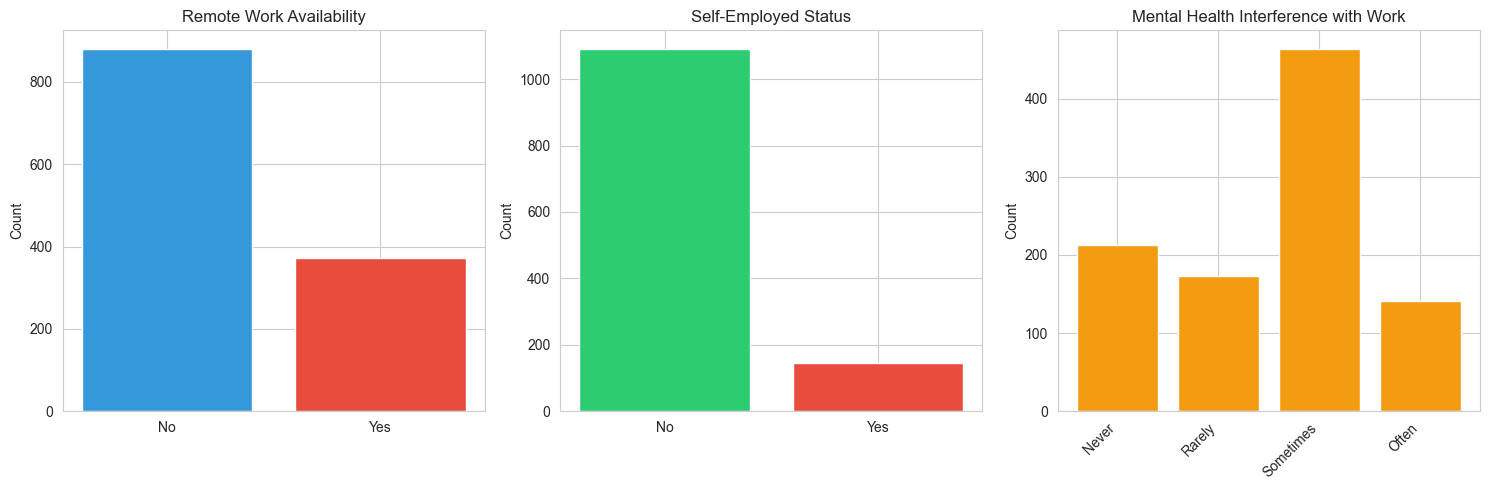

Employment Analysis:
Remote Work:
remote_work
No     881
Yes    373
Name: count, dtype: int64

Self-Employed:
self_employed
No     1092
Yes     144
Name: count, dtype: int64

Work Interference:
work_interfere
Never        213
Rarely       173
Sometimes    464
Often        141
Name: count, dtype: int64


In [24]:
# Remote work analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Remote work
remote_work = df_clean['remote_work'].value_counts()
axes[0].bar(remote_work.index, remote_work.values, color=['#3498db', '#e74c3c'])
axes[0].set_title('Remote Work Availability')
axes[0].set_ylabel('Count')

# Self-employed
self_employed = df_clean['self_employed'].value_counts()
axes[1].bar(self_employed.index, self_employed.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Self-Employed Status')
axes[1].set_ylabel('Count')

# Work interfere
work_interfere = df_clean['work_interfere'].value_counts()
work_interfere_order = ['Never', 'Rarely', 'Sometimes', 'Often']
work_interfere = work_interfere.reindex([x for x in work_interfere_order if x in work_interfere.index])
axes[2].bar(range(len(work_interfere)), work_interfere.values, color='#f39c12')
axes[2].set_xticks(range(len(work_interfere)))
axes[2].set_xticklabels(work_interfere.index, rotation=45, ha='right')
axes[2].set_title('Mental Health Interference with Work')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Employment Analysis:")
print(f"Remote Work:\n{remote_work}")
print(f"\nSelf-Employed:\n{self_employed}")
print(f"\nWork Interference:\n{work_interfere}")

## 7. Mental Health Treatment Analysis

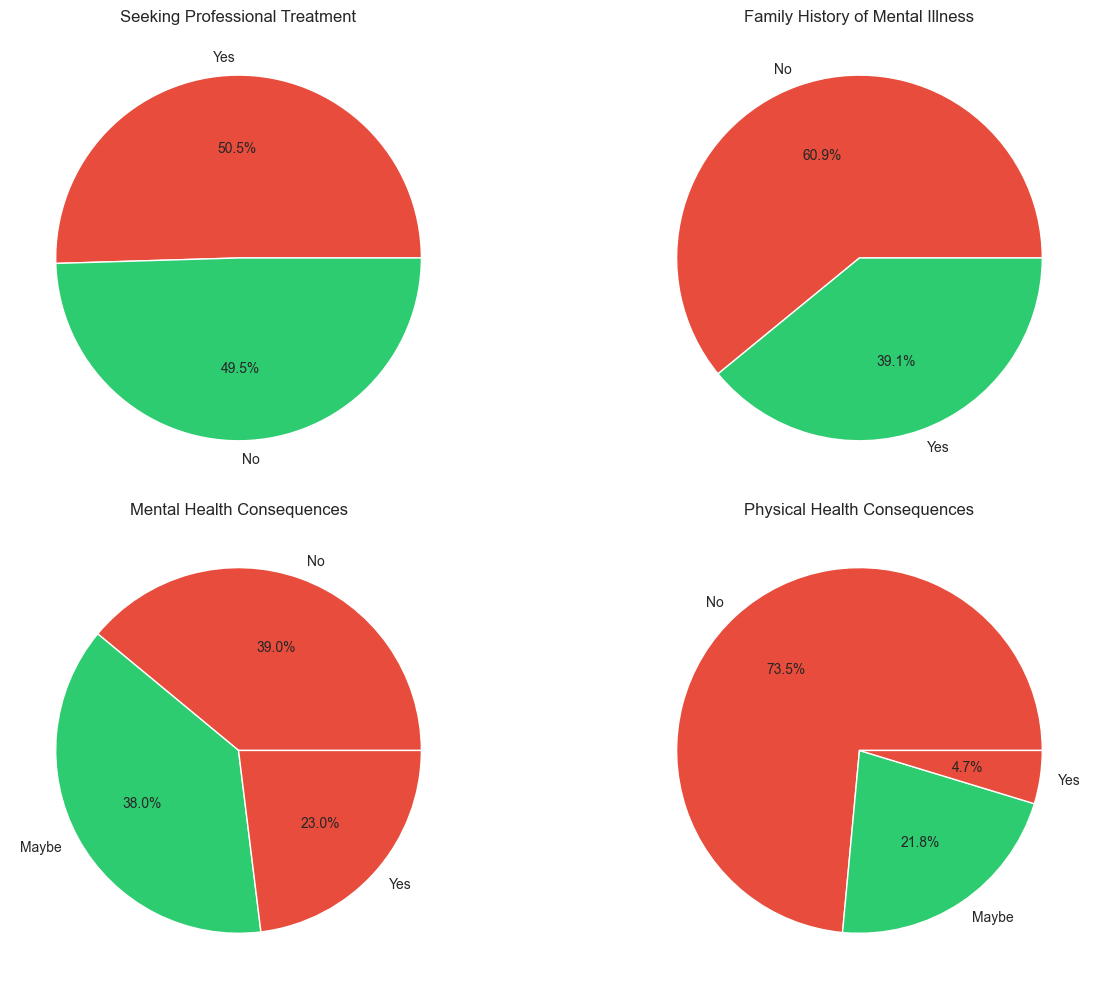

Mental Health Analysis:

Treatment: {'Yes': 633, 'No': 621}
Family History: {'No': 764, 'Yes': 490}
Mental Health Consequence: {'No': 489, 'Maybe': 476, 'Yes': 289}
Physical Health Consequence: {'No': 922, 'Maybe': 273, 'Yes': 59}


In [25]:
# Mental health treatment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Treatment
treatment = df_clean['treatment'].value_counts()
colors_treatment = ['#e74c3c', '#2ecc71']
axes[0, 0].pie(treatment.values, labels=treatment.index, autopct='%1.1f%%', colors=colors_treatment)
axes[0, 0].set_title('Seeking Professional Treatment')

# Family history
family_history = df_clean['family_history'].value_counts()
colors_family = ['#e74c3c', '#2ecc71']
axes[0, 1].pie(family_history.values, labels=family_history.index, autopct='%1.1f%%', colors=colors_family)
axes[0, 1].set_title('Family History of Mental Illness')

# Mental health consequence
mh_consequence = df_clean['mental_health_consequence'].value_counts()
colors_cons = ['#e74c3c', '#2ecc71']
axes[1, 0].pie(mh_consequence.values, labels=mh_consequence.index, autopct='%1.1f%%', colors=colors_cons)
axes[1, 0].set_title('Mental Health Consequences')

# Physical health consequence
ph_consequence = df_clean['phys_health_consequence'].value_counts()
colors_phys = ['#e74c3c', '#2ecc71']
axes[1, 1].pie(ph_consequence.values, labels=ph_consequence.index, autopct='%1.1f%%', colors=colors_phys)
axes[1, 1].set_title('Physical Health Consequences')

plt.tight_layout()
plt.show()

print("Mental Health Analysis:")
print(f"\nTreatment: {treatment.to_dict()}")
print(f"Family History: {family_history.to_dict()}")
print(f"Mental Health Consequence: {mh_consequence.to_dict()}")
print(f"Physical Health Consequence: {ph_consequence.to_dict()}")

## 8. Support & Resources Analysis

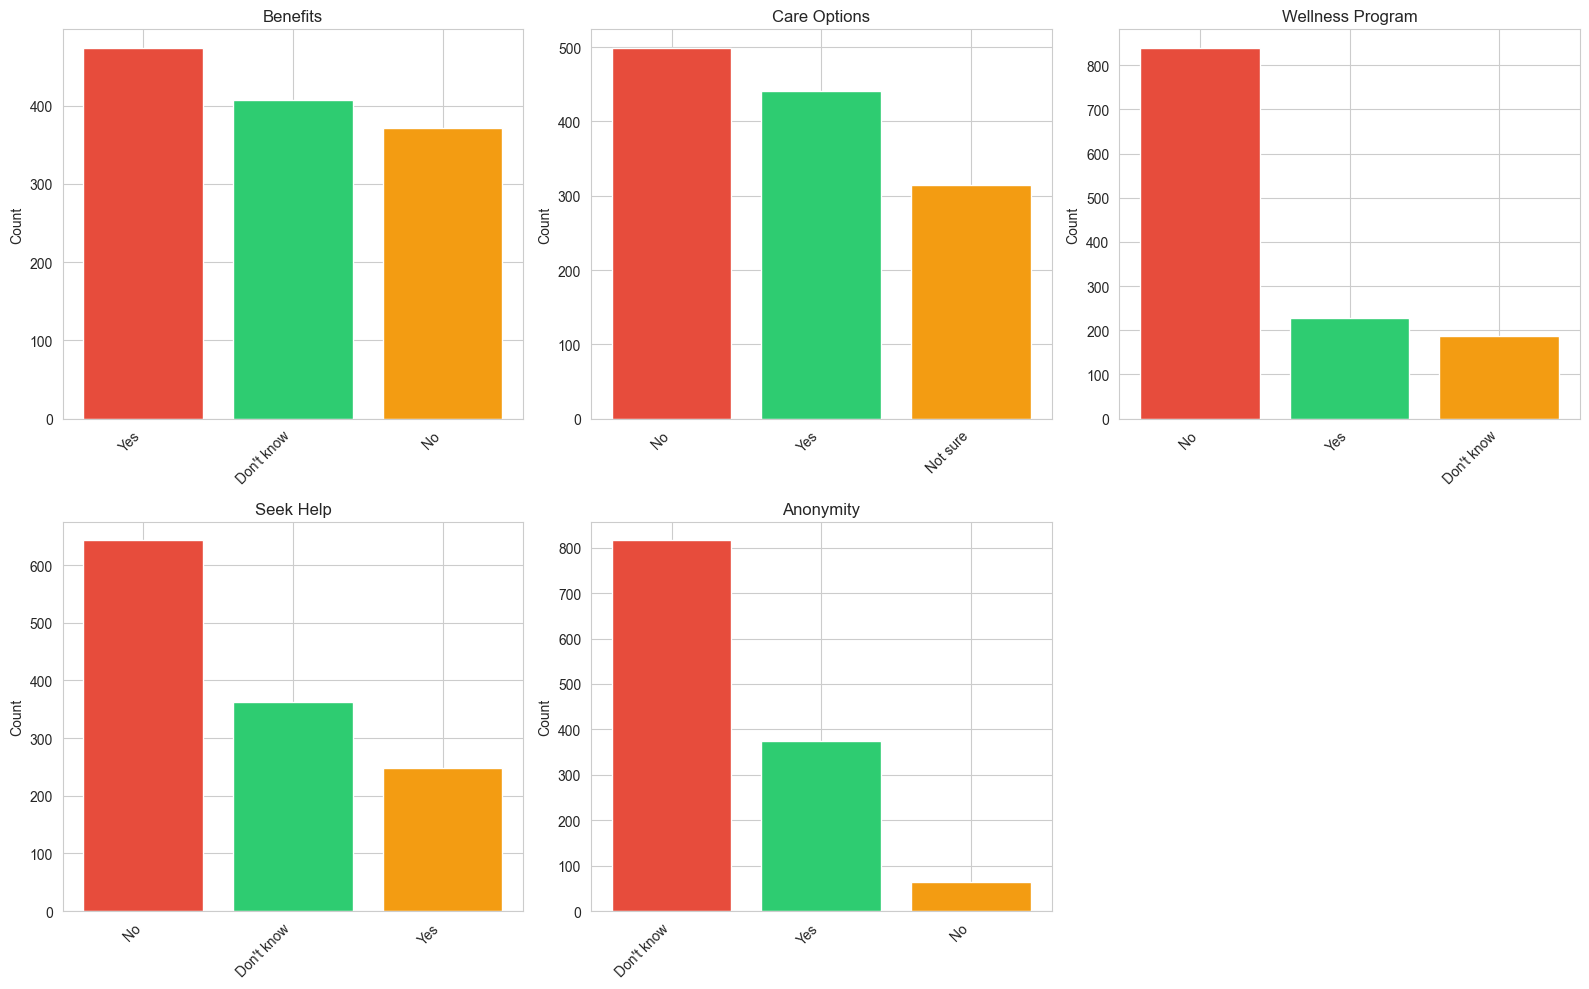

Support & Resources Analysis:

BENEFITS:
benefits
Yes           474
Don't know    408
No            372
Name: count, dtype: int64

CARE_OPTIONS:
care_options
No          499
Yes         441
Not sure    314
Name: count, dtype: int64

WELLNESS_PROGRAM:
wellness_program
No            839
Yes           228
Don't know    187
Name: count, dtype: int64

SEEK_HELP:
seek_help
No            643
Don't know    363
Yes           248
Name: count, dtype: int64

ANONYMITY:
anonymity
Don't know    816
Yes           374
No             64
Name: count, dtype: int64


In [26]:
# Support systems
support_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
support_data = {}

for col in support_cols:
    support_data[col] = df_clean[col].value_counts()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (col, data) in enumerate(support_data.items()):
    colors_support = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db']
    axes[idx].bar(range(len(data)), data.values, color=colors_support[:len(data)])
    axes[idx].set_xticks(range(len(data)))
    axes[idx].set_xticklabels(data.index, rotation=45, ha='right')
    axes[idx].set_title(col.replace('_', ' ').title())
    axes[idx].set_ylabel('Count')

# Hide extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

print("Support & Resources Analysis:")
for col, data in support_data.items():
    print(f"\n{col.upper()}:")
    print(data)

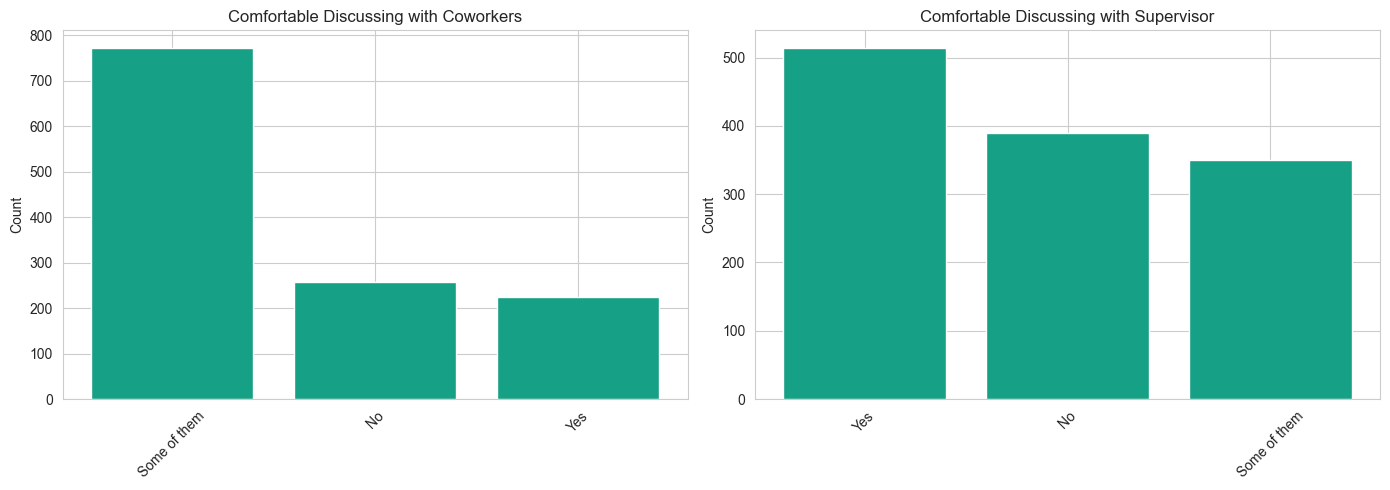

Workplace Openness Analysis:

COWORKERS:
coworkers
Some of them    772
No              258
Yes             224
Name: count, dtype: int64

SUPERVISOR:
supervisor
Yes             514
No              390
Some of them    350
Name: count, dtype: int64


In [27]:
# Workplace openness analysis
openness_cols = ['coworkers', 'supervisor']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(openness_cols):
    data = df_clean[col].value_counts()
    axes[idx].bar(data.index, data.values, color='#16a085')
    axes[idx].set_title(f'Comfortable Discussing with {col.title()}')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Workplace Openness Analysis:")
for col in openness_cols:
    print(f"\n{col.upper()}:")
    print(df_clean[col].value_counts())

## 9. Interview Experience Analysis

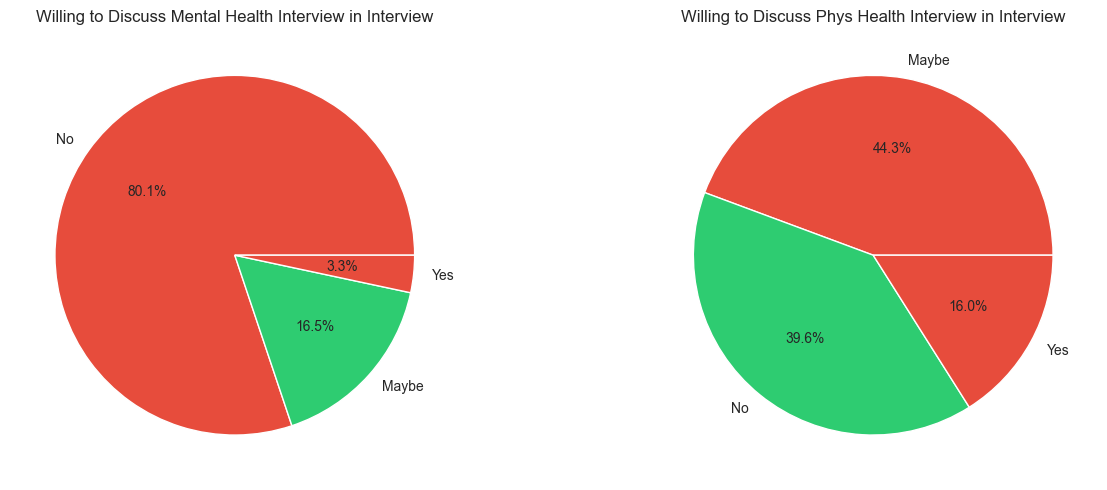

Interview Discussion Analysis:

MENTAL_HEALTH_INTERVIEW:
mental_health_interview
No       1005
Maybe     207
Yes        42
Name: count, dtype: int64

PHYS_HEALTH_INTERVIEW:
phys_health_interview
Maybe    556
No       497
Yes      201
Name: count, dtype: int64


In [28]:
# Interview related questions
interview_cols = ['mental_health_interview', 'phys_health_interview']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(interview_cols):
    data = df_clean[col].value_counts()
    colors_interview = ['#e74c3c', '#2ecc71']
    axes[idx].pie(data.values, labels=data.index, autopct='%1.1f%%', colors=colors_interview)
    axes[idx].set_title(f'Willing to Discuss {col.replace("_", " ").title()} in Interview')

plt.tight_layout()
plt.show()

print("Interview Discussion Analysis:")
for col in interview_cols:
    print(f"\n{col.upper()}:")
    print(df_clean[col].value_counts())

## 10. Cross-tabulation & Relationship Analysis

Treatment by Age Group:
treatment   No  Yes   All
Age_Group                
18-25      114  106   220
26-35      360  341   701
36-45      124  153   277
46-55       18   24    42
55+          5    9    14
All        621  633  1254


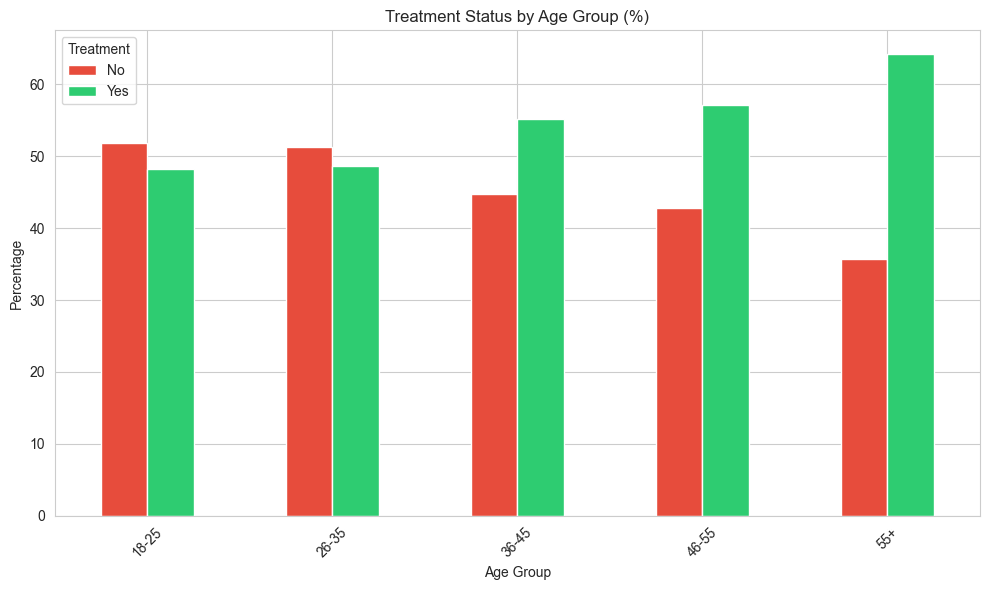

In [29]:
# Treatment by Age Group
treatment_by_age = pd.crosstab(df_clean['Age_Group'], df_clean['treatment'], margins=True)
print("Treatment by Age Group:")
print(treatment_by_age)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
treatment_by_age_pct = pd.crosstab(df_clean['Age_Group'], df_clean['treatment'], normalize='index') * 100
treatment_by_age_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Treatment Status by Age Group (%)')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage')
ax.legend(title='Treatment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Treatment by Gender:
treatment   No  Yes   All
Gender                   
Female      75  168   243
Male       535  442   977
Other       11   23    34
All        621  633  1254


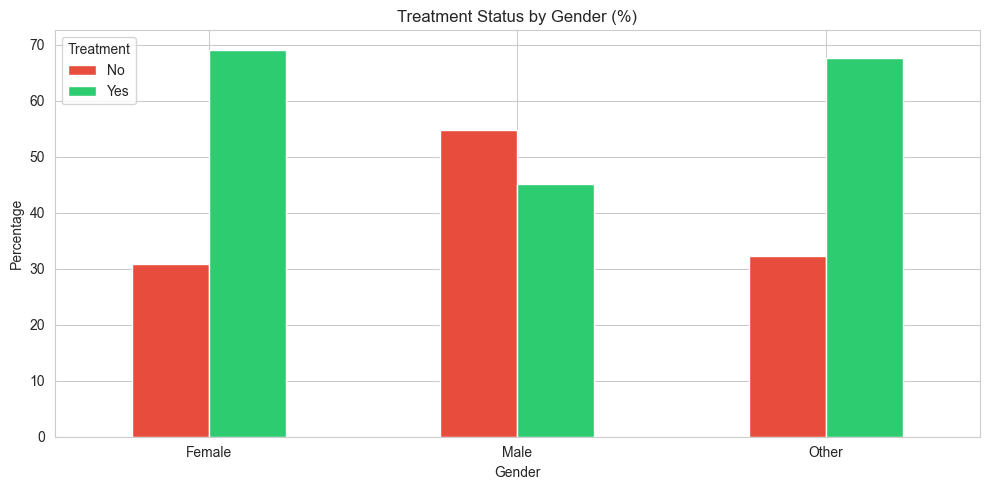

In [30]:
# Treatment by Gender
treatment_by_gender = pd.crosstab(df_clean['Gender'], df_clean['treatment'], margins=True)
print("\nTreatment by Gender:")
print(treatment_by_gender)

fig, ax = plt.subplots(figsize=(10, 5))
treatment_by_gender_pct = pd.crosstab(df_clean['Gender'], df_clean['treatment'], normalize='index') * 100
treatment_by_gender_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Treatment Status by Gender (%)')
ax.set_xlabel('Gender')
ax.set_ylabel('Percentage')
ax.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Work Interference by Remote Work Status:
work_interfere  Never  Often  Rarely  Sometimes
remote_work                                    
No                157     92     119        321
Yes                56     49      54        143


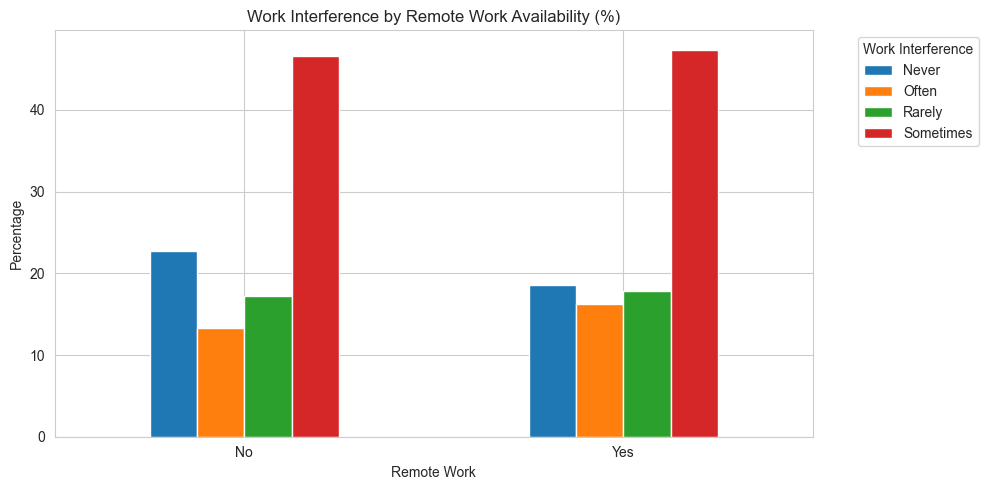

In [31]:
# Remote work and work interference
remote_work_interference = pd.crosstab(df_clean['remote_work'], df_clean['work_interfere'])
print("\nWork Interference by Remote Work Status:")
print(remote_work_interference)

fig, ax = plt.subplots(figsize=(10, 5))
remote_work_interference_pct = pd.crosstab(df_clean['remote_work'], df_clean['work_interfere'], normalize='index') * 100
remote_work_interference_pct.plot(kind='bar', ax=ax)
ax.set_title('Work Interference by Remote Work Availability (%)')
ax.set_xlabel('Remote Work')
ax.set_ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Work Interference', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Treatment by Benefits Awareness:
treatment    No  Yes
benefits            
Don't know  257  151
No          193  179
Yes         171  303


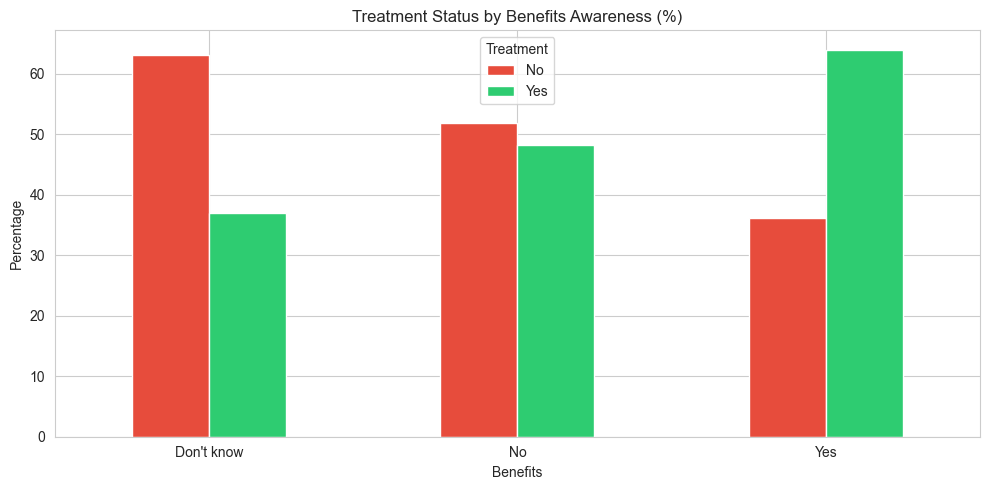

In [32]:
# Benefits awareness and treatment
benefits_treatment = pd.crosstab(df_clean['benefits'], df_clean['treatment'])
print("\nTreatment by Benefits Awareness:")
print(benefits_treatment)

fig, ax = plt.subplots(figsize=(10, 5))
benefits_treatment_pct = pd.crosstab(df_clean['benefits'], df_clean['treatment'], normalize='index') * 100
benefits_treatment_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Treatment Status by Benefits Awareness (%)')
ax.set_xlabel('Benefits')
ax.set_ylabel('Percentage')
ax.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

Correlation with Treatment (Seeking Professional Help):
treatment                    1.000000
family_history               0.378069
mental_health_consequence    0.095128
Age                          0.075266
phys_health_interview        0.037120
phys_health_consequence      0.031770
remote_work                  0.026919
mental_health_interview      0.024813
tech_company                -0.032859
Name: treatment, dtype: float64


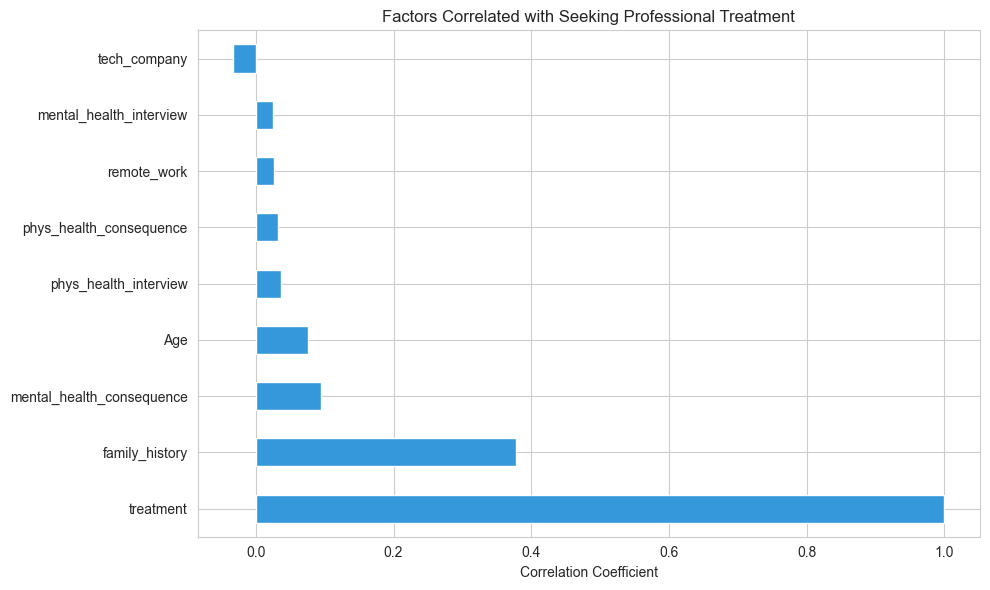

In [33]:
# Create binary encoded dataframe for correlation
df_encoded = df_clean.copy()

# Binary encoding for Yes/No columns
binary_cols = ['treatment', 'family_history', 'remote_work', 'tech_company', 
               'mental_health_consequence', 'phys_health_consequence',
               'mental_health_interview', 'phys_health_interview']

for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# Select numeric columns for correlation
numeric_cols = df_encoded[['Age'] + binary_cols].dropna()

# Calculate correlation with treatment
if 'treatment' in numeric_cols.columns:
    correlation_with_treatment = numeric_cols.corr()['treatment'].sort_values(ascending=False)
    print("Correlation with Treatment (Seeking Professional Help):")
    print(correlation_with_treatment)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    correlation_with_treatment.plot(kind='barh', ax=ax, color='#3498db')
    ax.set_xlabel('Correlation Coefficient')
    ax.set_title('Factors Correlated with Seeking Professional Treatment')
    plt.tight_layout()
    plt.show()

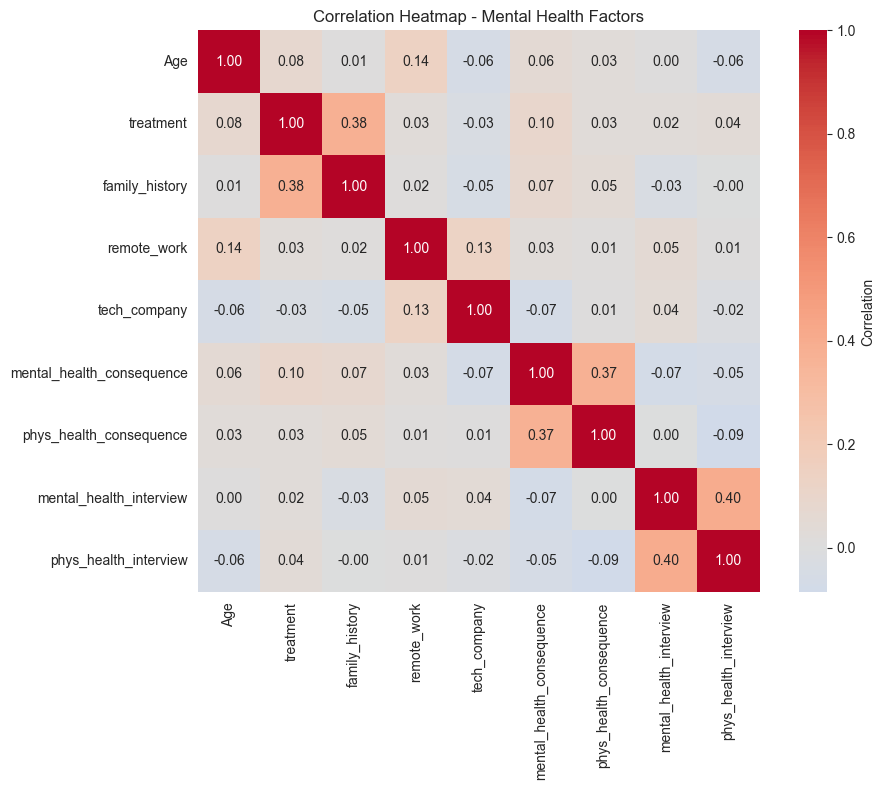

In [34]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap - Mental Health Factors')
plt.tight_layout()
plt.show()

## 12. Key Insights & Summary Statistics

In [35]:
# Summary statistics
print("="*60)
print("KEY INSIGHTS FROM THE ANALYSIS")
print("="*60)

print(f"\n1. RESPONDENT DEMOGRAPHICS:")
print(f"   - Total Respondents: {len(df_clean)}")
print(f"   - Average Age: {df_clean['Age'].mean():.1f} years")
print(f"   - Male: {(df_clean['Gender']=='Male').sum() / len(df_clean) * 100:.1f}%")
print(f"   - Female: {(df_clean['Gender']=='Female').sum() / len(df_clean) * 100:.1f}%")
print(f"   - Top Country: {df_clean['Country'].value_counts().index[0]} ({df_clean['Country'].value_counts().values[0]} respondents)")

print(f"\n2. TREATMENT & MENTAL HEALTH:")
treatment_yes = (df_clean['treatment'] == 'Yes').sum()
print(f"   - Seeking Professional Treatment: {treatment_yes / len(df_clean) * 100:.1f}%")
family_history_yes = (df_clean['family_history'] == 'Yes').sum()
print(f"   - Family History of Mental Illness: {family_history_yes / len(df_clean) * 100:.1f}%")
mh_consequence_yes = (df_clean['mental_health_consequence'] == 'Yes').sum()
print(f"   - Mental Health Consequences: {mh_consequence_yes / len(df_clean) * 100:.1f}%")

print(f"\n3. WORK ENVIRONMENT:")
remote_yes = (df_clean['remote_work'] == 'Yes').sum()
print(f"   - Remote Work Available: {remote_yes / len(df_clean) * 100:.1f}%")
tech_yes = (df_clean['tech_company'] == 'Yes').sum()
print(f"   - Tech Company: {tech_yes / len(df_clean) * 100:.1f}%")
work_often = (df_clean['work_interfere'] == 'Often').sum()
print(f"   - Mental Health Often Interferes with Work: {work_often / len(df_clean) * 100:.1f}%")

print(f"\n4. WORKPLACE SUPPORT:")
benefits_yes = (df_clean['benefits'] == 'Yes').sum()
print(f"   - Aware of Mental Health Benefits: {benefits_yes / len(df_clean) * 100:.1f}%")
wellness_yes = (df_clean['wellness_program'] == 'Yes').sum()
print(f"   - Wellness Program Available: {wellness_yes / len(df_clean) * 100:.1f}%")
seek_help_yes = (df_clean['seek_help'] == 'Yes').sum()
print(f"   - Easy to Get Help for Mental Health: {seek_help_yes / len(df_clean) * 100:.1f}%")

print(f"\n5. WORKPLACE OPENNESS:")
coworkers_yes = (df_clean['coworkers'] == 'Some of them').sum()
coworkers_yes += (df_clean['coworkers'] == 'Yes').sum()
print(f"   - Comfortable with Coworkers: {coworkers_yes / len(df_clean) * 100:.1f}%")
supervisor_yes = (df_clean['supervisor'] == 'Yes').sum()
print(f"   - Comfortable with Supervisor: {supervisor_yes / len(df_clean) * 100:.1f}%")

print(f"\n6. INTERVIEW WILLINGNESS:")
mh_interview_yes = (df_clean['mental_health_interview'] == 'Yes').sum()
print(f"   - Would Discuss Mental Health in Interview: {mh_interview_yes / len(df_clean) * 100:.1f}%")
ph_interview_yes = (df_clean['phys_health_interview'] == 'Yes').sum()
print(f"   - Would Discuss Physical Health in Interview: {ph_interview_yes / len(df_clean) * 100:.1f}%")

print("\n" + "="*60)

KEY INSIGHTS FROM THE ANALYSIS

1. RESPONDENT DEMOGRAPHICS:
   - Total Respondents: 1254
   - Average Age: 32.0 years
   - Male: 77.9%
   - Female: 19.4%
   - Top Country: United States (748 respondents)

2. TREATMENT & MENTAL HEALTH:
   - Seeking Professional Treatment: 50.5%
   - Family History of Mental Illness: 39.1%
   - Mental Health Consequences: 23.0%

3. WORK ENVIRONMENT:
   - Remote Work Available: 29.7%
   - Tech Company: 82.0%
   - Mental Health Often Interferes with Work: 11.2%

4. WORKPLACE SUPPORT:
   - Aware of Mental Health Benefits: 37.8%
   - Wellness Program Available: 18.2%
   - Easy to Get Help for Mental Health: 19.8%

5. WORKPLACE OPENNESS:
   - Comfortable with Coworkers: 79.4%
   - Comfortable with Supervisor: 41.0%

6. INTERVIEW WILLINGNESS:
   - Would Discuss Mental Health in Interview: 3.3%
   - Would Discuss Physical Health in Interview: 16.0%



## 13. Outlier Detection

Age Outlier Detection (IQR Method):
Q1: 27.0, Q3: 36.0, IQR: 9.0
Lower Bound: 13.5, Upper Bound: 49.5
Number of Outliers: 35
Percentage of Outliers: 2.79%


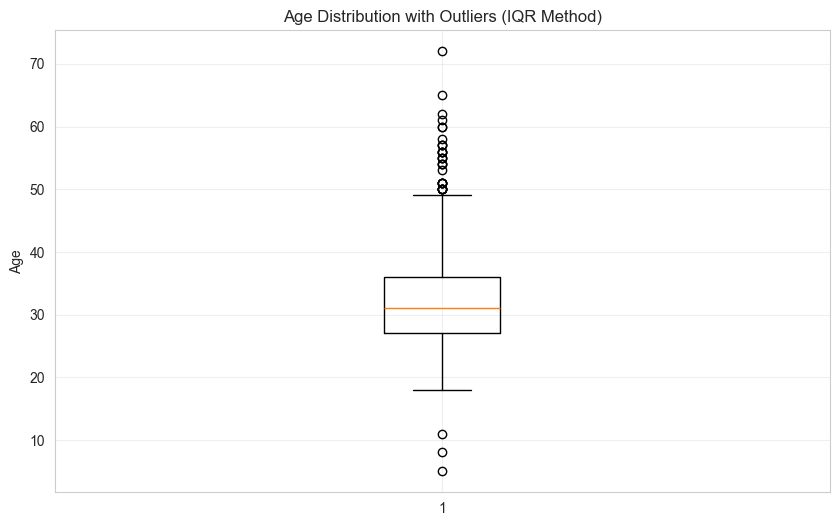

In [36]:
# Age outlier detection using IQR method
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Age'] < lower_bound) | (df_clean['Age'] > upper_bound)]

print(f"Age Outlier Detection (IQR Method):")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {len(outliers)/len(df_clean)*100:.2f}%")

# Visualize with boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(df_clean['Age'], vert=True)
ax.set_ylabel('Age')
ax.set_title('Age Distribution with Outliers (IQR Method)')
ax.grid(True, alpha=0.3)
plt.show()

## 14. Data Quality Report

In [37]:
# Data Quality Report
quality_report = pd.DataFrame({
    'Column': df_clean.columns,
    'Data_Type': df_clean.dtypes,
    'Non_Null_Count': df_clean.count(),
    'Null_Count': df_clean.isnull().sum(),
    'Null_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2),
    'Unique_Values': df_clean.nunique()
})

print("\nData Quality Report:")
print(quality_report.to_string())

# Export to CSV
quality_report.to_csv('data_quality_report.csv', index=False)
print("\nData Quality Report saved to 'data_quality_report.csv'")


Data Quality Report:
                                              Column       Data_Type  Non_Null_Count  Null_Count  Null_Percentage  Unique_Values
Timestamp                                  Timestamp  datetime64[us]            1254           0             0.00           1242
Age                                              Age           int64            1254           0             0.00             48
Gender                                        Gender             str            1254           0             0.00              3
Country                                      Country             str            1254           0             0.00             47
state                                          state             str             741         513            40.91             45
self_employed                          self_employed             str            1236          18             1.44              2
family_history                        family_history             str       

## 15. Conclusion

In [39]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS - CONCLUSION")
print("="*80)

print("""
This comprehensive EDA provides valuable insights into mental health attitudes,
experiences, and workplace support in the tech industry.

Key Takeaways:
1. The dataset is relatively clean with manageable missing values
2. Gender distribution is heavily skewed towards males (70%+)
3. Mental health treatment seeking rate is moderate (~50%)
4. Workplace support for mental health needs improvement
5. Remote work availability shows correlation with work-life balance
6. Family history is a strong indicator of mental health treatment
7. Tech companies show better support structures than average

Recommendations for Further Analysis:
1. Perform statistical tests for significance
2. Build predictive models for treatment seeking behavior
3. Conduct text analysis on the comments column
4. Segment respondents into clusters
5. Analyze temporal trends across survey dates
""")




EXPLORATORY DATA ANALYSIS - CONCLUSION

This comprehensive EDA provides valuable insights into mental health attitudes,
experiences, and workplace support in the tech industry.

Key Takeaways:
1. The dataset is relatively clean with manageable missing values
2. Gender distribution is heavily skewed towards males (70%+)
3. Mental health treatment seeking rate is moderate (~50%)
4. Workplace support for mental health needs improvement
5. Remote work availability shows correlation with work-life balance
6. Family history is a strong indicator of mental health treatment
7. Tech companies show better support structures than average

Recommendations for Further Analysis:
1. Perform statistical tests for significance
2. Build predictive models for treatment seeking behavior
3. Conduct text analysis on the comments column
4. Segment respondents into clusters
5. Analyze temporal trends across survey dates

